# Instrucciones para elaborar la tarea modelo

Este notebook analiza el evento del 5 al 8 de marzo de 2012 usando los archivos exportados por `GuiaDeInstalacionDeHAPI.ipynb`.




# Metodologia

El notebook se divide en dos capas. La primera capa trabaja con los productos observacionales ya descargados a CSV y JSON. La segunda capa deja un punto de entrada controlado para resultados CCMC.




In [32]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")

EVENT_START = pd.Timestamp("2012-03-05T00:00:00Z")
EVENT_STOP = pd.Timestamp("2012-03-08T00:00:00Z")
DATA_DIR = Path("data/hapi_tareamodelo")
CCMC_DIR = Path("data/ccmc")

print(f"Ventana del evento: {EVENT_START} -> {EVENT_STOP}")
print(f"Directorio de datos HAPI: {DATA_DIR.resolve()}")
print(f"Directorio CCMC esperado: {CCMC_DIR.resolve()}")


Ventana del evento: 2012-03-05 00:00:00+00:00 -> 2012-03-08 00:00:00+00:00
Directorio de datos HAPI: /Volumes/T7/tarea3-astroparticulas/data/hapi_tareamodelo
Directorio CCMC esperado: /Volumes/T7/tarea3-astroparticulas/data/ccmc


## Inventario local de productos HAPI

El analisis usa primero los archivos locales. Si algun producto no esta disponible, el notebook lo marca como faltante y sigue con el resto.


In [33]:
expected_products = [
    {"slug": "dst_final", "label": "Dst", "group": "indices", "required": True},
    {"slug": "noaa_kp_observed", "label": "Kp observado", "group": "indices", "required": True},
    {"slug": "swpc_rtsw_plasma", "label": "Plasma SWPC", "group": "solar_wind", "required": True},
    {"slug": "intermagnet_abk_field_magnitude", "label": "INTERMAGNET ABK", "group": "ground", "required": False},
    {"slug": "intermagnet_mea_field_magnitude", "label": "INTERMAGNET MEA", "group": "ground", "required": False},
    {"slug": "intermagnet_sjg_field_magnitude", "label": "INTERMAGNET SJG", "group": "ground", "required": True},
    {"slug": "intermagnet_hua_field_magnitude", "label": "INTERMAGNET HUA", "group": "ground", "required": False},
    {"slug": "intermagnet_kep_field_magnitude", "label": "INTERMAGNET KEP", "group": "ground", "required": False},
    {"slug": "ace_mfi_magnitude_bgsm", "label": "ACE MFI", "group": "solar_wind", "required": False},
    {"slug": "omni_hro2_5min", "label": "OMNI 5 min", "group": "solar_wind", "required": False},
    {"slug": "geotail_cpi_plasma", "label": "GEOTAIL CPI", "group": "solar_wind", "required": False},
    {"slug": "gps_roti_south", "label": "GPS ROTI South", "group": "ionosphere", "required": False},
    {"slug": "lasco_c3_urls", "label": "LASCO C3 URLs", "group": "imagery", "required": False},
]

availability_rows = []
for item in expected_products:
    csv_path = DATA_DIR / f"{item['slug']}.csv"
    metadata_path = DATA_DIR / f"{item['slug']}.metadata.json"
    availability_rows.append(
        {
            "slug": item["slug"],
            "label": item["label"],
            "group": item["group"],
            "required": item["required"],
            "csv_exists": csv_path.exists(),
            "metadata_exists": metadata_path.exists(),
            "csv_path": str(csv_path),
        }
    )

availability = pd.DataFrame(availability_rows)
display(availability)

missing_required = availability.loc[availability["required"] & ~availability["csv_exists"], "slug"].tolist()
if missing_required:
    print("Faltan productos requeridos:", ", ".join(missing_required))
else:
    print("Todos los productos requeridos para el analisis base estan disponibles.")


,slug,label,group,required,csv_exists,metadata_exists,csv_path
0,dst_final,Dst,indices,True,True,True,data/hapi_tareamodelo/dst_final.csv
1,noaa_kp_observed,Kp observado,indices,True,True,True,data/hapi_tareamodelo/noaa_kp_observed.csv
2,swpc_rtsw_plasma,Plasma SWPC,solar_wind,True,True,True,data/hapi_tareamodelo/swpc_rtsw_plasma.csv
3,intermagnet_abk_field_magnitude,INTERMAGNET ABK,ground,False,True,True,data/hapi_tareamodelo/intermagnet_abk_field_ma...
4,intermagnet_mea_field_magnitude,INTERMAGNET MEA,ground,False,True,True,data/hapi_tareamodelo/intermagnet_mea_field_ma...
5,intermagnet_sjg_field_magnitude,INTERMAGNET SJG,ground,True,True,True,data/hapi_tareamodelo/intermagnet_sjg_field_ma...
6,intermagnet_hua_field_magnitude,INTERMAGNET HUA,ground,False,True,True,data/hapi_tareamodelo/intermagnet_hua_field_ma...
7,intermagnet_kep_field_magnitude,INTERMAGNET KEP,ground,False,False,False,data/hapi_tareamodelo/intermagnet_kep_field_ma...
8,ace_mfi_magnitude_bgsm,ACE MFI,solar_wind,False,False,False,data/hapi_tareamodelo/ace_mfi_magnitude_bgsm.csv
9,omni_hro2_5min,OMNI 5 min,solar_wind,False,False,False,data/hapi_tareamodelo/omni_hro2_5min.csv


Todos los productos requeridos para el analisis base estan disponibles.


# Analisis de Datos Observacionales

A partir de aqui el notebook trabaja con los archivos ya exportados. 


In [34]:
def load_csv(slug):
    path = DATA_DIR / f"{slug}.csv"
    if not path.exists():
        return None
    frame = pd.read_csv(path, parse_dates=["Time"])
    frame["Time"] = pd.to_datetime(frame["Time"], utc=True)
    frame = frame.set_index("Time").sort_index()
    return frame


def load_metadata(slug):
    path = DATA_DIR / f"{slug}.metadata.json"
    if not path.exists():
        return {}
    return json.loads(path.read_text(encoding="utf-8"))


datasets = {}
metadata = {}
loaded_rows = []

for slug in availability.loc[availability["csv_exists"], "slug"]:
    frame = load_csv(slug)
    datasets[slug] = frame
    metadata[slug] = load_metadata(slug)
    loaded_rows.append(
        {
            "slug": slug,
            "rows": len(frame),
            "columns": ", ".join(frame.columns),
            "start": frame.index.min(),
            "stop": frame.index.max(),
        }
    )

loaded_summary = pd.DataFrame(loaded_rows).sort_values("slug").reset_index(drop=True)
display(loaded_summary)


,slug,rows,columns,start,stop
0,dst_final,72,Dst,2012-03-05 00:00:00+00:00,2012-03-07 23:00:00+00:00
1,intermagnet_abk_field_magnitude,4320,Field_Magnitude,2012-03-05 00:00:00+00:00,2012-03-07 23:59:00+00:00
2,intermagnet_hua_field_magnitude,4320,Field_Magnitude,2012-03-05 00:00:00+00:00,2012-03-07 23:59:00+00:00
3,intermagnet_mea_field_magnitude,4320,Field_Magnitude,2012-03-05 00:00:00+00:00,2012-03-07 23:59:00+00:00
4,intermagnet_sjg_field_magnitude,4320,Field_Magnitude,2012-03-05 00:00:00+00:00,2012-03-07 23:59:00+00:00
5,lasco_c3_urls,314,url,2012-03-05 00:06:06+00:00,2012-03-07 23:56:39+00:00
6,noaa_kp_observed,24,Kp_observed,2012-03-05 00:00:00+00:00,2012-03-07 21:00:00+00:00
7,swpc_rtsw_plasma,4320,"ProtonDensity, IonTemperature",2012-03-05 00:00:00+00:00,2012-03-07 23:59:00+00:00


## Dst y Kp

Estos dos indices permiten ubicar las fases de la perturbacion geomagnetica y sirven como referencia para comparar el resto de las observaciones.


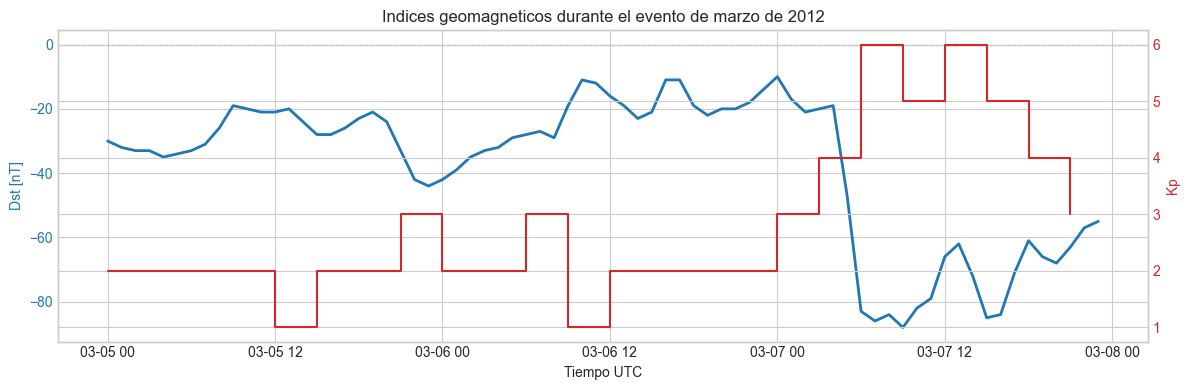

In [35]:
dst = datasets.get("dst_final")
kp = datasets.get("noaa_kp_observed")

fig, ax1 = plt.subplots(figsize=(12, 4))

if dst is not None:
    ax1.plot(dst.index, dst["Dst"], color="tab:blue", linewidth=2, label="Dst")
    ax1.set_ylabel("Dst [nT]", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")
    ax1.axhline(0, color="black", linewidth=0.8, linestyle="--")

ax2 = ax1.twinx()
if kp is not None:
    kp_hourly = kp["Kp_observed"].resample("1h").ffill()
    ax2.step(kp_hourly.index, kp_hourly, where="post", color="tab:red", linewidth=1.5, label="Kp")
    ax2.set_ylabel("Kp", color="tab:red")
    ax2.tick_params(axis="y", labelcolor="tab:red")

ax1.set_title("Indices geomagneticos durante el evento de marzo de 2012")
ax1.set_xlabel("Tiempo UTC")
plt.tight_layout()
plt.show()


,Dst,Kp,ProtonDensity,IonTemperature
2012-03-05 00:00:00+00:00,-30.0,2.0,-1497.083333,19783.333333
2012-03-05 01:00:00+00:00,-32.0,2.0,-1663.800000,18473.333333
2012-03-05 02:00:00+00:00,-33.0,2.0,-1163.813333,22278.333333
2012-03-05 03:00:00+00:00,-33.0,2.0,-1497.280000,16810.000000
2012-03-05 04:00:00+00:00,-35.0,2.0,-997.003333,21536.666667
2012-03-05 05:00:00+00:00,-34.0,2.0,-1496.846667,19965.000000
2012-03-05 06:00:00+00:00,-33.0,2.0,-1332.018333,48855.000000
2012-03-05 07:00:00+00:00,-31.0,2.0,-1332.908333,47948.333333
2012-03-05 08:00:00+00:00,-26.0,2.0,-1331.063333,19960.000000
2012-03-05 09:00:00+00:00,-19.0,2.0,-997.725000,21828.333333


,Dst,Kp,ProtonDensity,IonTemperature
Dst,1.00,-0.85,0.32,-0.49
Kp,-0.85,1.00,-0.36,0.63
ProtonDensity,0.32,-0.36,1.00,-0.04
IonTemperature,-0.49,0.63,-0.04,1.00


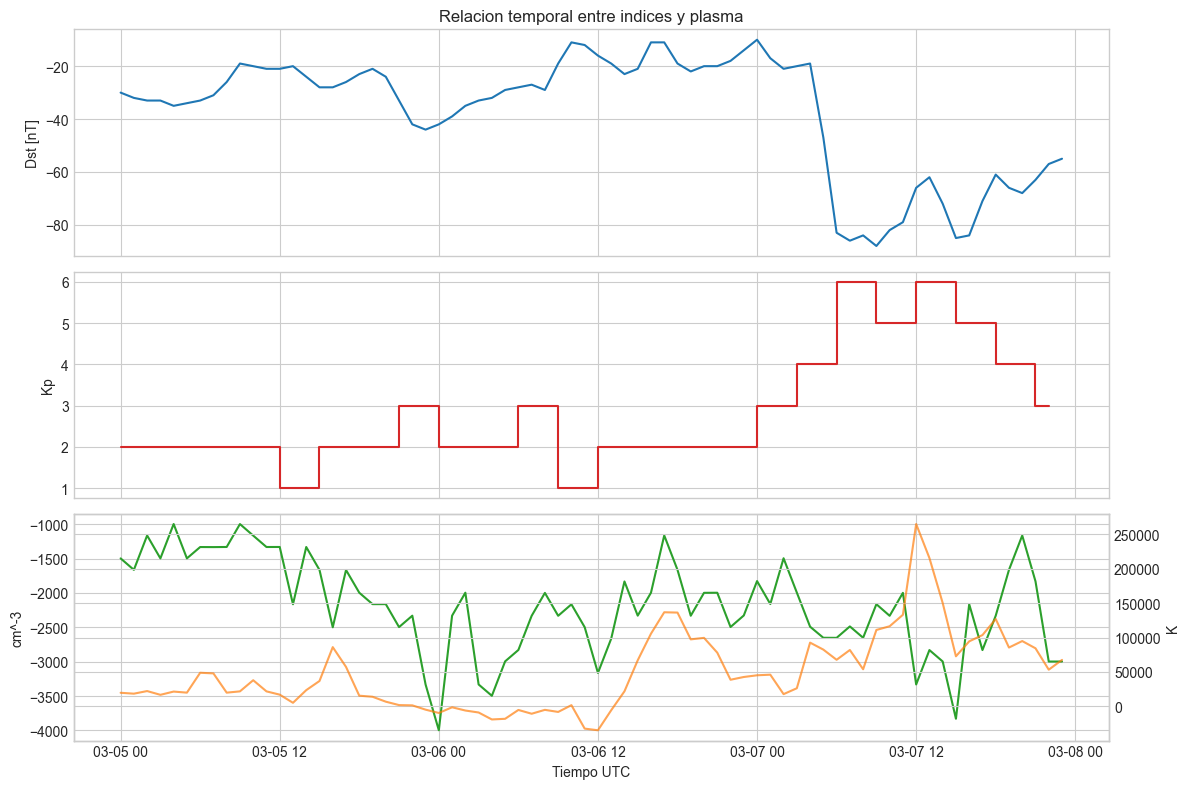

In [36]:
analysis_hourly = pd.DataFrame(index=pd.date_range(EVENT_START, EVENT_STOP, freq="1h", inclusive="left"))

if dst is not None:
    analysis_hourly["Dst"] = dst["Dst"].resample("1h").mean()
if kp is not None:
    analysis_hourly["Kp"] = kp["Kp_observed"].resample("1h").ffill()
if "swpc_rtsw_plasma" in datasets:
    swpc = datasets["swpc_rtsw_plasma"].resample("1h").mean()
    analysis_hourly["ProtonDensity"] = swpc["ProtonDensity"]
    analysis_hourly["IonTemperature"] = swpc["IonTemperature"]

display(analysis_hourly.head(12))
display(analysis_hourly.corr(numeric_only=True).round(2))

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

if "Dst" in analysis_hourly:
    axes[0].plot(analysis_hourly.index, analysis_hourly["Dst"], color="tab:blue")
    axes[0].set_ylabel("Dst [nT]")
    axes[0].set_title("Relacion temporal entre indices y plasma")

if "Kp" in analysis_hourly:
    axes[1].step(analysis_hourly.index, analysis_hourly["Kp"], where="post", color="tab:red")
    axes[1].set_ylabel("Kp")

if "ProtonDensity" in analysis_hourly:
    axes[2].plot(analysis_hourly.index, analysis_hourly["ProtonDensity"], color="tab:green", label="Densidad")
    axes[2].set_ylabel("cm^-3")
    ax_temp = axes[2].twinx()
    ax_temp.plot(analysis_hourly.index, analysis_hourly["IonTemperature"], color="tab:orange", alpha=0.7, label="Temperatura")
    ax_temp.set_ylabel("K")

axes[2].set_xlabel("Tiempo UTC")
plt.tight_layout()
plt.show()


## Magnetometros terrestres de INTERMAGNET

Los magnetometros permiten observar como responde el campo geomagnetico en estaciones con distinta ubicacion geografica. Para comparar estaciones, se muestra tanto la magnitud absoluta como la perturbacion respecto a una linea base calculada con las primeras 6 horas del intervalo.


,ABK,HUA,MEA,SJG
Time,,,,
2012-03-05 00:00:00+00:00,53029.637907,NaN,57801.019480,37532.352959
2012-03-05 01:00:00+00:00,53002.426386,NaN,57803.977497,37531.437150
2012-03-05 02:00:00+00:00,53021.145702,NaN,57811.524386,37528.097604
2012-03-05 03:00:00+00:00,53063.423645,NaN,57811.206131,37528.696431
2012-03-05 04:00:00+00:00,53050.754553,NaN,57817.276138,37529.887945


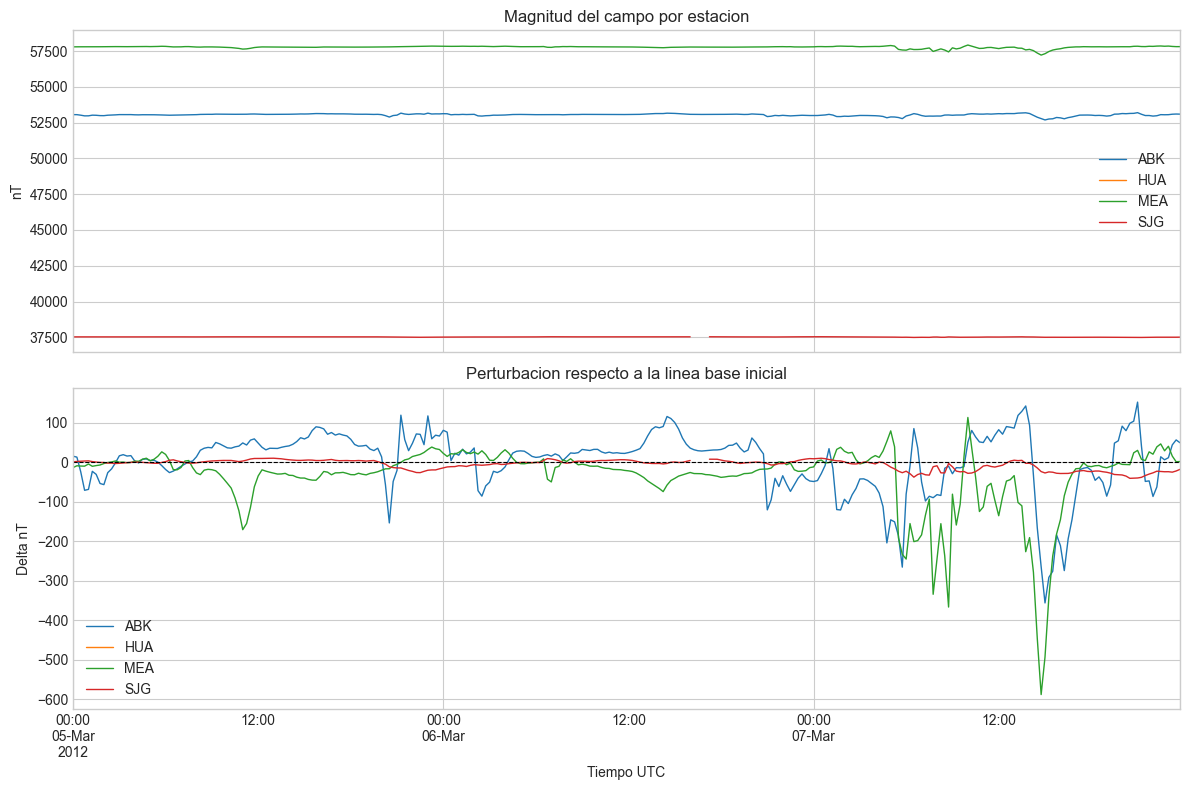

In [37]:
magnetometer_slugs = sorted(slug for slug in datasets if slug.startswith("intermagnet_"))
magnetometer_data = {}

for slug in magnetometer_slugs:
    station = slug.split("_")[1].upper()
    series = datasets[slug]["Field_Magnitude"].replace(99999.0, np.nan)
    magnetometer_data[station] = series

magnetic_field = pd.DataFrame(magnetometer_data).sort_index()
baseline_end = EVENT_START + pd.Timedelta(hours=6)
baseline = magnetic_field.loc[EVENT_START:baseline_end].median()
magnetic_delta = magnetic_field - baseline

display(magnetic_field.resample("1h").mean().head())

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
magnetic_field.resample("15min").mean().plot(ax=axes[0], linewidth=1)
axes[0].set_title("Magnitud del campo por estacion")
axes[0].set_ylabel("nT")

magnetic_delta.resample("15min").mean().plot(ax=axes[1], linewidth=1)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Perturbacion respecto a la linea base inicial")
axes[1].set_ylabel("Delta nT")
axes[1].set_xlabel("Tiempo UTC")

plt.tight_layout()
plt.show()


## Productos solares e ionosfericos adicionales

ACE, OMNI, GEOTAIL y ROTI faltan



,slug,csv_exists,metadata_exists
8,ace_mfi_magnitude_bgsm,False,False
9,omni_hro2_5min,False,False
10,geotail_cpi_plasma,False,False
11,gps_roti_south,False,False


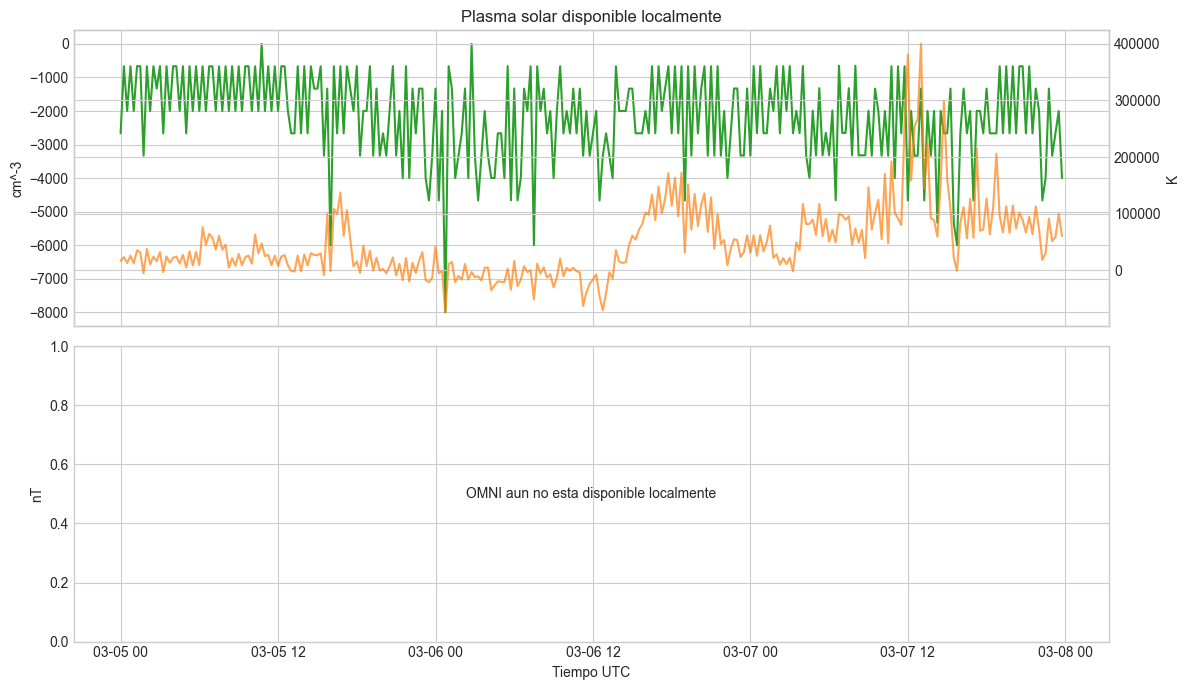

In [38]:
optional_slugs = [
    "ace_mfi_magnitude_bgsm",
    "omni_hro2_5min",
    "geotail_cpi_plasma",
    "gps_roti_south",
]

display(availability.loc[availability["slug"].isin(optional_slugs), ["slug", "csv_exists", "metadata_exists"]])

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

if "swpc_rtsw_plasma" in datasets:
    swpc_15m = datasets["swpc_rtsw_plasma"].resample("15min").mean()
    axes[0].plot(swpc_15m.index, swpc_15m["ProtonDensity"], color="tab:green")
    axes[0].set_ylabel("cm^-3")
    axes[0].set_title("Plasma solar disponible localmente")
    ax_temp = axes[0].twinx()
    ax_temp.plot(swpc_15m.index, swpc_15m["IonTemperature"], color="tab:orange", alpha=0.7)
    ax_temp.set_ylabel("K")
else:
    axes[0].text(0.5, 0.5, "No hay plasma SWPC local", ha="center", va="center", transform=axes[0].transAxes)

if "omni_hro2_5min" in datasets:
    omni = datasets["omni_hro2_5min"]
    axes[1].plot(omni.index, omni["BZ_GSM"], color="tab:purple", label="Bz GSM")
    axes[1].set_ylabel("nT")
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, "OMNI aun no esta disponible localmente", ha="center", va="center", transform=axes[1].transAxes)
    axes[1].set_ylabel("nT")

axes[1].set_xlabel("Tiempo UTC")
plt.tight_layout()
plt.show()


## Imagenes LASCO C3

El archivo de URLs de LASCO no se grafica como serie fisica, pero sirve para documentar el contexto solar y construir una lista reproducible de imagenes asociadas al evento.


In [39]:
lasco = datasets.get("lasco_c3_urls")
if lasco is not None:
    cadence_minutes = lasco.index.to_series().diff().dropna().dt.total_seconds().div(60)
    print(f"Numero de imagenes listadas: {len(lasco)}")
    if not cadence_minutes.empty:
        print(f"Cadencia mediana: {cadence_minutes.median():.1f} minutos")
    display(lasco.head(10))
else:
    print("No existe un archivo LASCO local para este evento.")


Numero de imagenes listadas: 314
Cadencia mediana: 12.0 minutos


,url
Time,
2012-03-05 00:06:06+00:00,https://helioviewer.org/jp2/LASCO-C2/2012/03/0...
2012-03-05 00:18:06+00:00,https://helioviewer.org/jp2/LASCO-C2/2012/03/0...
2012-03-05 00:30:07+00:00,https://helioviewer.org/jp2/LASCO-C2/2012/03/0...
2012-03-05 00:42:05+00:00,https://helioviewer.org/jp2/LASCO-C2/2012/03/0...
2012-03-05 00:54:06+00:00,https://helioviewer.org/jp2/LASCO-C2/2012/03/0...
2012-03-05 01:30:25+00:00,https://helioviewer.org/jp2/LASCO-C2/2012/03/0...
2012-03-05 01:42:07+00:00,https://helioviewer.org/jp2/LASCO-C2/2012/03/0...
2012-03-05 01:54:05+00:00,https://helioviewer.org/jp2/LASCO-C2/2012/03/0...
2012-03-05 02:06:07+00:00,https://helioviewer.org/jp2/LASCO-C2/2012/03/0...


# Resultados de Modelos CCMC



In [40]:
ccmc_files = sorted(path.name for path in CCMC_DIR.glob("*") if path.is_file()) if CCMC_DIR.exists() else []
if ccmc_files:
    display(pd.DataFrame({"archivo": ccmc_files}))
else:
    print("No se encontraron archivos CCMC locales en data/ccmc.")

ENLIL_FILE = None

if ENLIL_FILE:
    enlil_path = Path(ENLIL_FILE)
    if enlil_path.exists():
        try:
            import enlilviz as ev
            import enlilviz.plotting as evplot

            run = ev.read_enlil2d(str(enlil_path))
            forecaster = evplot.ForecasterPlot(run)
            plt.show()
        except Exception as exc:
            print(f"No se pudo abrir el archivo ENLIL: {exc}")
    else:
        print(f"Ruta ENLIL no encontrada: {enlil_path}")
else:
    print("Defina ENLIL_FILE con la ruta de un netCDF local para incorporar la parte CCMC.")


No se encontraron archivos CCMC locales en data/ccmc.
Defina ENLIL_FILE con la ruta de un netCDF local para incorporar la parte CCMC.


# Conclusiones

Este bloque resume automaticamente lo mas relevante del conjunto local disponible. Puede usarlo como base para redactar la discusion final de la tarea.


In [41]:
summary_lines = []

if dst is not None:
    dst_min_time = dst["Dst"].idxmin()
    dst_min_value = float(dst["Dst"].min())
    summary_lines.append(f"- Dst minimo: {dst_min_value:.1f} nT en {dst_min_time:%Y-%m-%d %H:%M UTC}.")

if kp is not None:
    kp_max_time = kp["Kp_observed"].idxmax()
    kp_max_value = float(kp["Kp_observed"].max())
    summary_lines.append(f"- Kp maximo: {kp_max_value:.1f} en {kp_max_time:%Y-%m-%d %H:%M UTC}.")

if "swpc_rtsw_plasma" in datasets:
    swpc_frame = datasets["swpc_rtsw_plasma"]
    density_peak_time = swpc_frame["ProtonDensity"].idxmax()
    density_peak_value = float(swpc_frame["ProtonDensity"].max())
    summary_lines.append(
        f"- Densidad de protones maxima: {density_peak_value:.1f} cm^-3 en {density_peak_time:%Y-%m-%d %H:%M UTC}."
    )

if "magnetic_delta" in globals() and not magnetic_delta.empty:
    station_peaks = magnetic_delta.abs().max().sort_values(ascending=False)
    top_station = station_peaks.index[0]
    top_value = float(station_peaks.iloc[0])
    summary_lines.append(f"- Mayor perturbacion magnetica relativa: {top_station} con {top_value:.1f} nT.")

missing_products = availability.loc[~availability["csv_exists"], "slug"].tolist()
if missing_products:
    summary_lines.append("- Productos aun no disponibles localmente: " + ", ".join(missing_products) + ".")

display(Markdown("\n".join(summary_lines)))


- Dst minimo: -88.0 nT en 2012-03-07 09:00 UTC.
- Kp maximo: 6.0 en 2012-03-07 06:00 UTC.
- Densidad de protones maxima: 29.4 cm^-3 en 2012-03-07 05:51 UTC.
- Mayor perturbacion magnetica relativa: MEA con 680.3 nT.
- Productos aun no disponibles localmente: intermagnet_kep_field_magnitude, ace_mfi_magnitude_bgsm, omni_hro2_5min, geotail_cpi_plasma, gps_roti_south.